#**Section 01: Drive Mount and Import Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [ ]:
FILE_PATH = '/content/drive/MyDrive/MS DS/Data Mining/Dengue_diseases_dataset_modified (1).csv'
df = pd.read_csv(FILE_PATH)

print(f"Shape: {df.shape}")
df.head()

Shape: (989, 9)


,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1


#**Section 2: Exploratory Data Analysis**

In [ ]:
# Basic info and summary statistics
print(df.dtypes)
df.describe()

age                              int64
gender                          object
hemoglobin_g_dl                float64
wbc_count                      float64
differential_count               int64
rbc_count                        int64
platelet_count                 float64
platelet_distribution_width    float64
dengue_label                     int64
dtype: object


,age,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
count,989.000000,989.000000,965.000000,989.000000,989.000000,973.000000,970.000000,989.000000
mean,42.199191,13.712942,4338.031088,0.939333,0.938322,114702.241521,22.848866,0.651163
std,20.941111,1.484111,2344.529755,0.238840,0.240692,89421.766107,14.692872,0.476843
min,3.000000,11.000000,2000.000000,0.000000,0.000000,10000.000000,1.000000,0.000000
25%,27.000000,12.600000,2600.000000,1.000000,1.000000,46000.000000,14.000000,0.000000
50%,40.000000,13.700000,3200.000000,1.000000,1.000000,93000.000000,17.800000,1.000000
75%,55.000000,15.000000,6200.000000,1.000000,1.000000,162500.000000,28.200000,1.000000
max,120.000000,25.000000,10900.000000,1.000000,1.000000,500000.000000,215.000000,1.000000


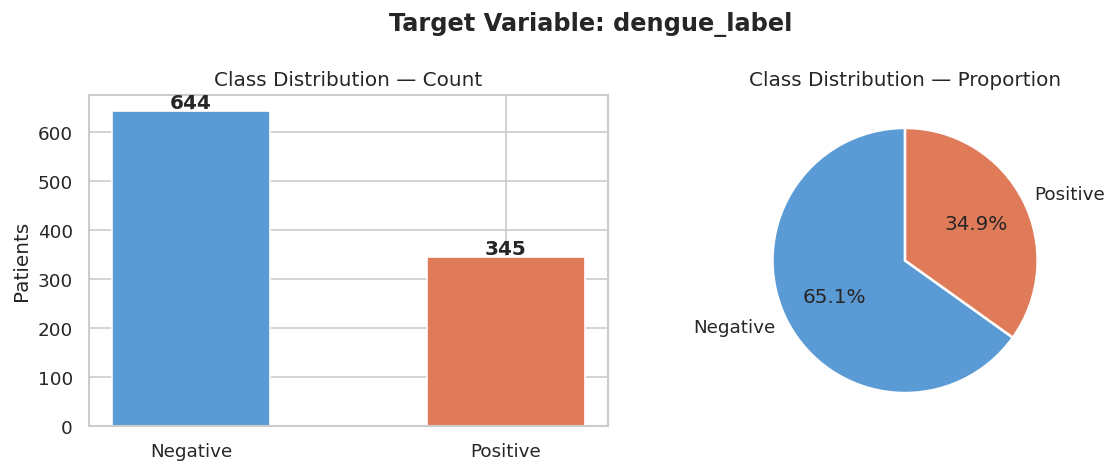

In [ ]:
# How many dengue positive vs negative patients
counts = df['dengue_label'].value_counts()
colors = ['#5B9BD5', '#E07B5A']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Negative', 'Positive'], counts.values, color=colors, width=0.5)
axes[0].set_title('Class Distribution — Count')
axes[0].set_ylabel('Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Negative', 'Positive'], colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution — Proportion')

plt.suptitle('Target Variable: dengue_label', fontweight='bold')
plt.tight_layout()
plt.show()

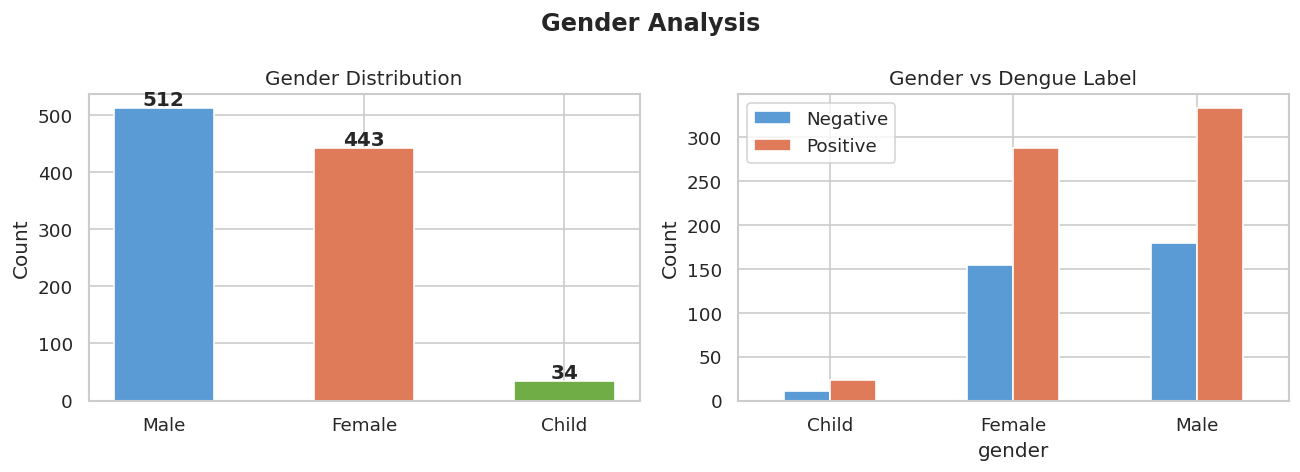

In [ ]:
# Overall gender counts and breakdown by dengue label
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

gender_counts = df['gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values,
            color=['#5B9BD5', '#E07B5A', '#70AD47'], width=0.5)
axes[0].set_title('Gender Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

df.groupby(['gender', 'dengue_label']).size().unstack().plot(
    kind='bar', ax=axes[1], color=['#5B9BD5', '#E07B5A'], edgecolor='white')
axes[1].set_title('Gender vs Dengue Label')
axes[1].set_ylabel('Count')
axes[1].legend(['Negative', 'Positive'])
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Gender Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

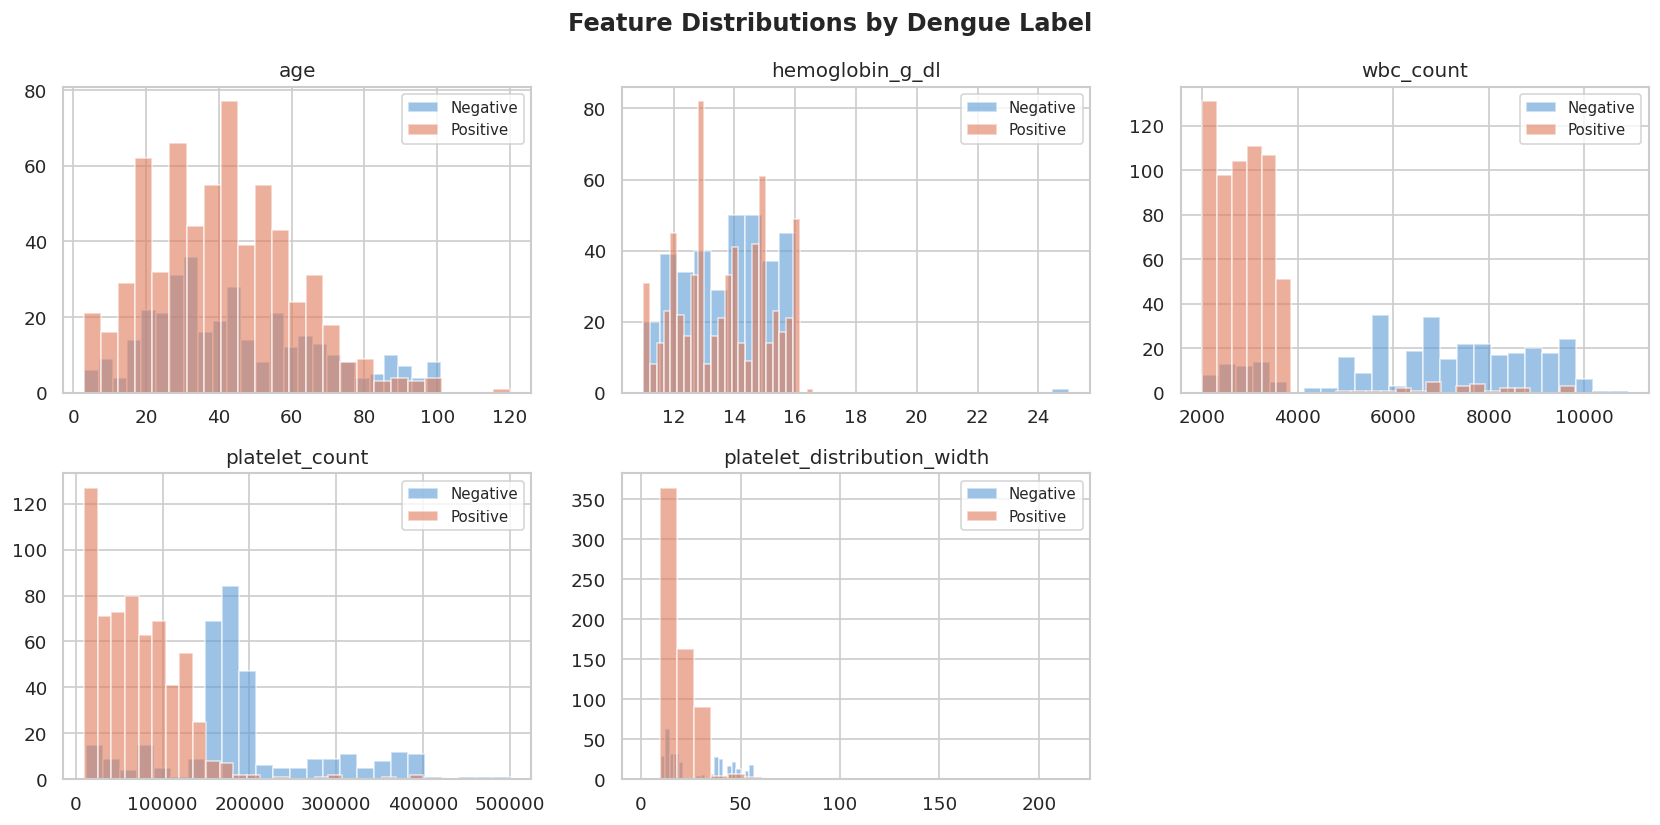

In [ ]:
# Distributions of numerical features split by dengue label
num_cols = ['age', 'hemoglobin_g_dl', 'wbc_count', 'platelet_count', 'platelet_distribution_width']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color, name in zip([0, 1], ['#5B9BD5', '#E07B5A'], ['Negative', 'Positive']):
        axes[i].hist(df[df['dengue_label'] == label][col].dropna(),
                     bins=25, alpha=0.6, color=color, edgecolor='white', label=name)
    axes[i].set_title(col)
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions by Dengue Label', fontweight='bold')
plt.tight_layout()
plt.show()

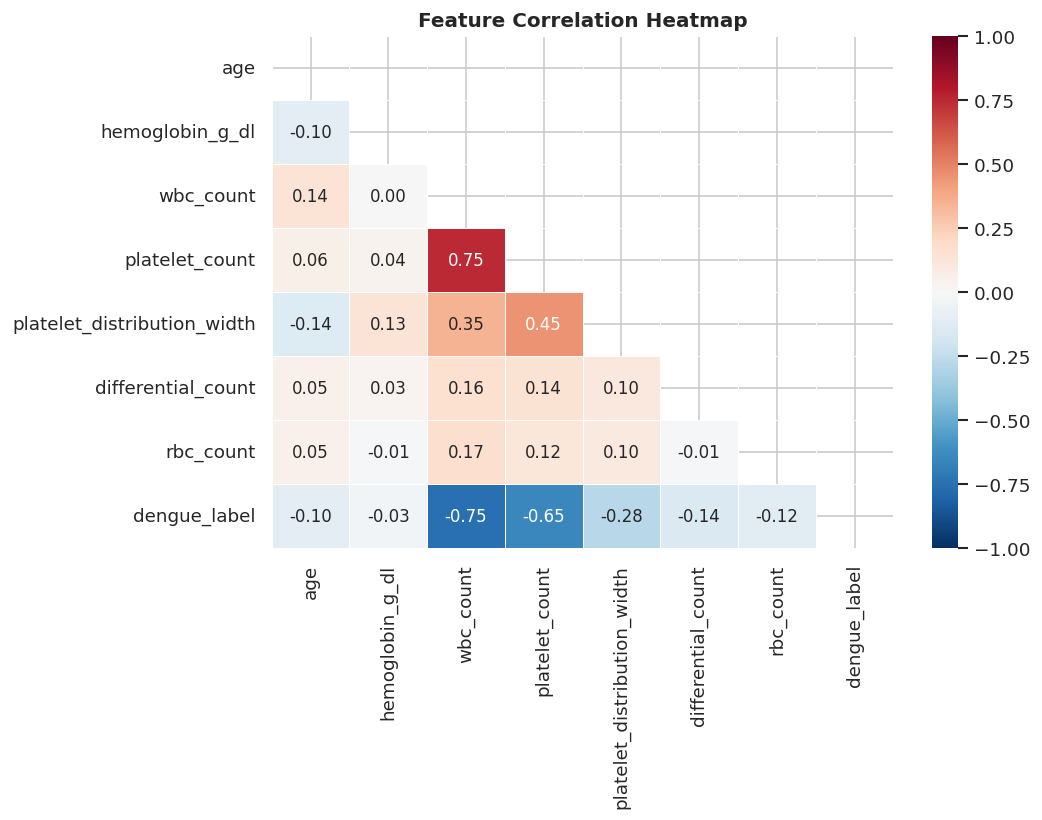

In [ ]:
# Correlation between all numerical features and target
corr_cols = ['age', 'hemoglobin_g_dl', 'wbc_count', 'platelet_count',
             'platelet_distribution_width', 'differential_count', 'rbc_count', 'dengue_label']

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(df[corr_cols].corr(), dtype=bool))
sns.heatmap(df[corr_cols].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 10})

plt.title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

#**Section 3: Preprocessing**

In [ ]:
# Which columns have missing values and how many
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                             Missing Count  Missing %
wbc_count                               24       2.43
platelet_count                          16       1.62
platelet_distribution_width             19       1.92


In [ ]:
# If |skewness| > 0.5 use median, otherwise mean
cols_to_impute = ['wbc_count', 'platelet_count', 'platelet_distribution_width']

for col in cols_to_impute:
    skew = df[col].skew()
    method = 'Median' if abs(skew) > 0.5 else 'Mean'
    print(f"{col:<35} skewness={skew:.3f}  → use {method}")

wbc_count                           skewness=1.036  → use Median
platelet_count                      skewness=1.329  → use Median
platelet_distribution_width         skewness=5.251  → use Median


In [ ]:
df_clean = df.copy()  # always work on a copy

# All three columns are skewed — use median for all
for col in cols_to_impute:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)
    print(f"{col} → filled with median: {median_val}")

print(f"\nMissing values remaining: {df_clean.isnull().sum().sum()} ")

wbc_count → filled with median: 3200.0
platelet_count → filled with median: 93000.0
platelet_distribution_width → filled with median: 17.8

Missing values remaining: 0 


In [ ]:
# 'Child' is an age group not a gender — extract as binary flag
df_clean['is_child'] = (df_clean['gender'] == 'Child').astype(int)
df_clean['gender'] = df_clean['gender'].replace('Child', 'Male')

print(df_clean['gender'].value_counts())
print(f"\nis_child counts:\n{df_clean['is_child'].value_counts()}")

gender
Male      546
Female    443
Name: count, dtype: int64

is_child counts:
is_child
0    955
1     34
Name: count, dtype: int64


In [ ]:
# differential_count and rbc_count are >93% constant — no predictive value
print("Variance — differential_count:", round(df_clean['differential_count'].var(), 4))
print("Variance — rbc_count         :", round(df_clean['rbc_count'].var(), 4))

df_clean.drop(columns=['differential_count', 'rbc_count'], inplace=True)
print(f"\n Dropped. Remaining columns: {df_clean.columns.tolist()}")

Variance — differential_count: 0.057
Variance — rbc_count         : 0.0579

 Dropped. Remaining columns: ['age', 'gender', 'hemoglobin_g_dl', 'wbc_count', 'platelet_count', 'platelet_distribution_width', 'dengue_label', 'is_child']


In [ ]:
# Cap outliers using IQR — preserves rows, limits extreme influence
def cap_iqr(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    print(f"{col:<35} capped: {before} outliers")

for col in ['age', 'platelet_distribution_width', 'platelet_count', 'wbc_count', 'hemoglobin_g_dl']:
    cap_iqr(df_clean, col)

age                                 capped: 13 outliers
platelet_distribution_width         capped: 47 outliers
platelet_count                      capped: 40 outliers
wbc_count                           capped: 1 outliers
hemoglobin_g_dl                     capped: 1 outliers


In [ ]:
# Binary column — label encoding is sufficient (Female=0, Male=1)
le = LabelEncoder()
df_clean['gender'] = le.fit_transform(df_clean['gender'])
print({cls: i for i, cls in enumerate(le.classes_)})

{'Female': 0, 'Male': 1}


In [ ]:
X = df_clean.drop(columns=['dengue_label'])
y = df_clean['dengue_label']

# Split before scaling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}  Test: {X_test.shape}")

# Fit scaler on train only — apply to both
cols_to_scale = ['age', 'hemoglobin_g_dl', 'wbc_count', 'platelet_count', 'platelet_distribution_width']
scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print(" Scaling done")

Train: (791, 7)  Test: (198, 7)
 Scaling done


#**Section 4: Feature Engineering**

In [ ]:
# platelet_wbc_ratio: dengue drops both simultaneously — ratio captures combined signal
X_train['platelet_wbc_ratio'] = X_train['platelet_count'] / (X_train['wbc_count'] + 1)
X_test['platelet_wbc_ratio']  = X_test['platelet_count']  / (X_test['wbc_count'] + 1)

print(f"✅ Feature added. New shape: {X_train.shape}")

✅ Feature added. New shape: (791, 8)


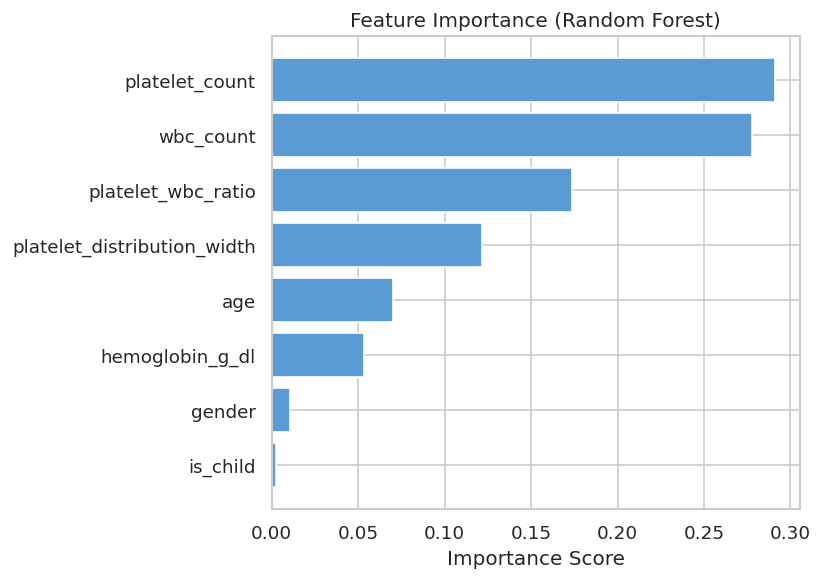

                    Feature  Importance
             platelet_count    0.290863
                  wbc_count    0.277578
         platelet_wbc_ratio    0.173931
platelet_distribution_width    0.121467
                        age    0.069871
            hemoglobin_g_dl    0.053148
                     gender    0.010806
                   is_child    0.002336


In [ ]:
# Quick Random Forest to rank features before final modeling
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_temp.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(7, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#5B9BD5')
plt.xlabel('Importance Score')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))

In [ ]:
# Drop features scoring below 0.01 — contribute almost nothing
THRESHOLD = 0.01
low = importance_df[importance_df['Importance'] < THRESHOLD]['Feature'].tolist()

X_train.drop(columns=low, inplace=True)
X_test.drop(columns=low, inplace=True)

print(f" Dropped: {low}")
print(f"Final features ({X_train.shape[1]}): {X_train.columns.tolist()}")

 Dropped: ['is_child']
Final features (7): ['age', 'gender', 'hemoglobin_g_dl', 'wbc_count', 'platelet_count', 'platelet_distribution_width', 'platelet_wbc_ratio']


#**Section 5: Model Training & Cross-Validation**

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(random_state=42),
    'XGBoost'            : XGBClassifier(random_state=42, verbosity=0)
}
print(" Models defined:", list(models.keys()))

 Models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']


In [ ]:
# 5-fold stratified CV — F1 as metric due to class imbalance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    print(f"{name:<25} F1: {scores.mean():.3f}")

Logistic Regression       F1: 0.929
Decision Tree             F1: 0.874
Random Forest             F1: 0.932
XGBoost                   F1: 0.917


In [ ]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained")

Logistic Regression trained
Decision Tree trained
Random Forest trained
XGBoost trained


In [ ]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model'   : name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'F1 Score': round(f1_score(y_test, y_pred), 3),
        'ROC-AUC' : round(roc_auc_score(y_test, y_prob), 3)
    })

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy  F1 Score  ROC-AUC
      Random Forest     0.924     0.943    0.916
Logistic Regression     0.914     0.936    0.899
            XGBoost     0.899     0.924    0.914
      Decision Tree     0.859     0.890    0.851


#**Section 6: Evaluation & Visualizations**

In [ ]:
for name, model in trained_models.items():
    print(f"=== {name} ===")
    print(classification_report(y_test, model.predict(X_test),
          target_names=['Negative', 'Positive']))

=== Logistic Regression ===
              precision    recall  f1-score   support

    Negative       0.93      0.81      0.87        69
    Positive       0.91      0.97      0.94       129

    accuracy                           0.91       198
   macro avg       0.92      0.89      0.90       198
weighted avg       0.92      0.91      0.91       198

=== Decision Tree ===
              precision    recall  f1-score   support

    Negative       0.78      0.83      0.80        69
    Positive       0.90      0.88      0.89       129

    accuracy                           0.86       198
   macro avg       0.84      0.85      0.85       198
weighted avg       0.86      0.86      0.86       198

=== Random Forest ===
              precision    recall  f1-score   support

    Negative       0.91      0.87      0.89        69
    Positive       0.93      0.95      0.94       129

    accuracy                           0.92       198
   macro avg       0.92      0.91      0.92       198
we

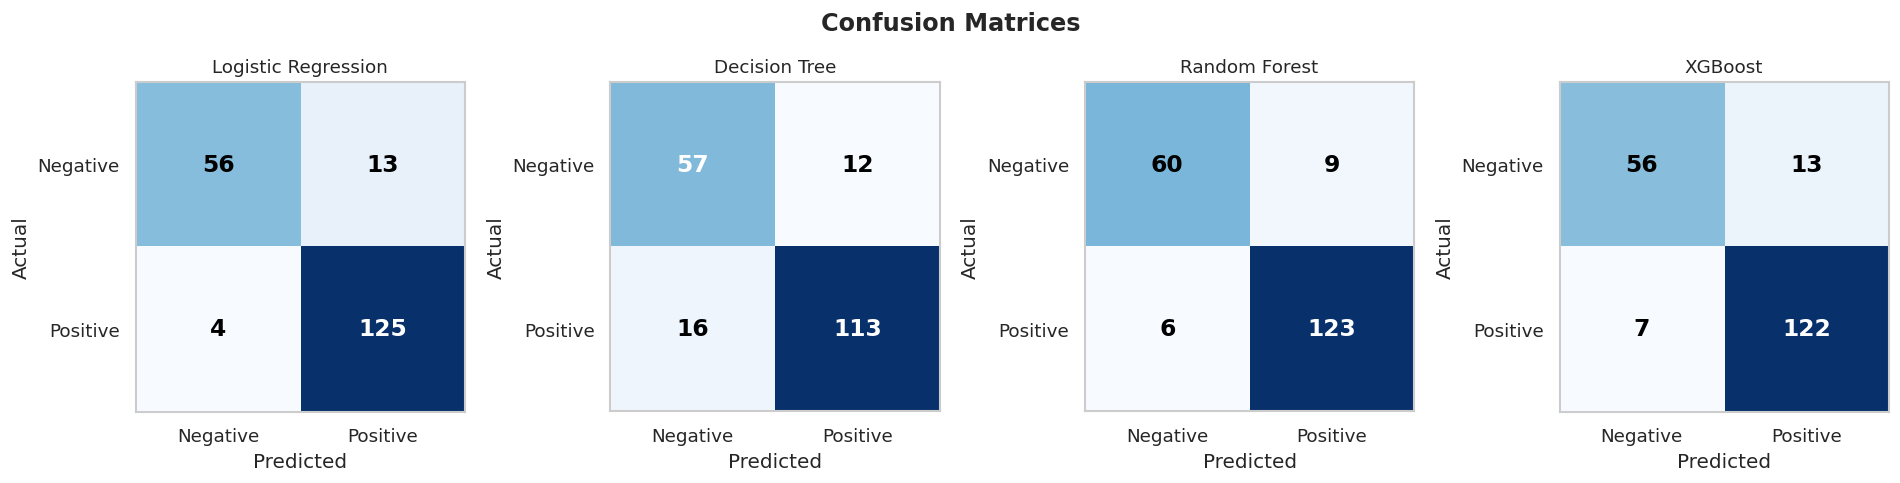

In [ ]:
# imshow-based confusion matrices — clean, no gridlines
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))

    im = ax.imshow(cm, cmap='Blues')

    # Annotate cells with counts
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Negative', 'Positive'])
    ax.set_yticklabels(['Negative', 'Positive'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(name, fontsize=11)
    ax.grid(False)  # no gridlines

plt.suptitle('Confusion Matrices', fontweight='bold')
plt.tight_layout()
plt.show()

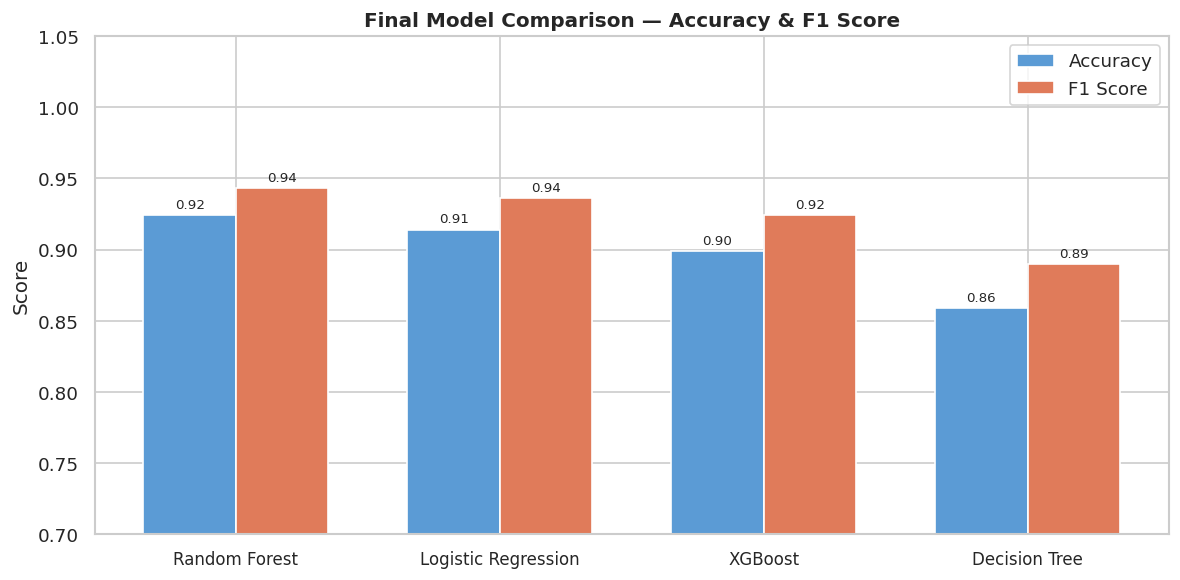

In [ ]:
metrics = ['Accuracy', 'F1 Score']
x       = range(len(results_df))
width   = 0.35   # slightly increased width since only 2 bars
colors  = ['#5B9BD5', '#E07B5A']

fig, ax = plt.subplots(figsize=(10, 5))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar([xi + (i - 0.5) * width for xi in x],
                  results_df[metric], width, label=metric, color=color)

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.2f}',
                ha='center', fontsize=8)

ax.set_xticks(list(x))
ax.set_xticklabels(results_df['Model'], fontsize=10)
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('Score')
ax.set_title('Final Model Comparison — Accuracy & F1 Score',fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()